In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision import transforms
from PIL import Image

In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
!wget https://github.com/SVizor42/ML_Zoomcamp/releases/download/straight-curly-data/data.zip

--2025-11-21 22:49:13--  https://github.com/SVizor42/ML_Zoomcamp/releases/download/straight-curly-data/data.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/405934815/e712cf72-f851-44e0-9c05-e711624af985?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-11-21T23%3A41%3A30Z&rscd=attachment%3B+filename%3Ddata.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-11-21T22%3A40%3A46Z&ske=2025-11-21T23%3A41%3A30Z&sks=b&skv=2018-11-09&sig=1xdlQwUrE3u2Z17pueo%2FpSf%2BNjLshuDbXq8UBFDTclg%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2Mzc2NzE1MywibmJmIjoxNzYzNzY1MzUzLCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHVjdG

In [4]:
!unzip data.zip

Archive:  data.zip
   creating: data/
   creating: data/test/
   creating: data/test/curly/
  inflating: data/test/curly/03312ac556a7d003f7570657f80392c34.jpg  
  inflating: data/test/curly/106dfcf4abe76990b585b2fc2e3c9f884.jpg  
  inflating: data/test/curly/1a9dbe23a0d95f1c292625960e4509184.jpg  
  inflating: data/test/curly/341ea26e6677b655f8447af56073204a4.jpg  
  inflating: data/test/curly/61aPFVrm42L._SL1352_.jpg  
  inflating: data/test/curly/6d8acb0fe980774ea4e5631198587f45.png  
  inflating: data/test/curly/7f5649a0c33a2b334f23221a52c16b9b.jpg  
  inflating: data/test/curly/90146673.jpg  
  inflating: data/test/curly/9b3608e01d78fbabc9fb0719323d507f4.jpg  
  inflating: data/test/curly/b171c99161f3cffc12d4b74488ef2fc6.jpg  
  inflating: data/test/curly/blogger_one.jpg  
  inflating: data/test/curly/c03ca1590aa4df74e922ad8257305a2b.jpg  
  inflating: data/test/curly/c1b89bb4f86a3478ec20ce1f63f003c1.jpg  
  inflating: data/test/curly/c5.jpg  
  inflating: data/test/curly/C86_76156

In [5]:
img = Image.open('/content/data/train/curly/00cbad1ffe22d900018e5a2e7376daed4.jpg')

array([[[ 95,  86,  71],
        [ 97,  88,  73],
        [ 97,  88,  73],
        ...,
        [146, 141, 119],
        [146, 141, 119],
        [148, 143, 121]],

       [[ 96,  87,  70],
        [ 98,  89,  72],
        [ 99,  89,  72],
        ...,
        [149, 144, 122],
        [147, 142, 120],
        [147, 142, 120]],

       [[ 98,  87,  68],
        [100,  89,  70],
        [101,  89,  71],
        ...,
        [149, 144, 122],
        [147, 142, 120],
        [148, 143, 121]],

       ...,

       [[116,  82,  57],
        [117,  83,  58],
        [118,  84,  59],
        ...,
        [220, 219, 214],
        [222, 221, 216],
        [224, 223, 218]],

       [[117,  83,  58],
        [119,  85,  60],
        [119,  85,  60],
        ...,
        [221, 220, 215],
        [222, 221, 216],
        [221, 220, 215]],

       [[120,  86,  61],
        [121,  87,  62],
        [119,  85,  60],
        ...,
        [220, 219, 214],
        [220, 219, 214],
        [221, 220, 215]]], dtype=uint8)
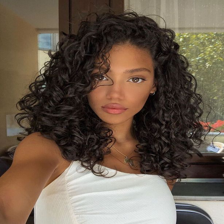

In [6]:
np.array(img.resize((224,224)))

#### Model
We will use Convolutional Neural Network (CNN). We'll use PyTorch.

Develop the model with following structure:

- The shape for input should be (3, 200, 200) (channels first format in PyTorch)
- Next, create a convolutional layer (nn.Conv2d):
  - Use 32 filters (output channels)
  - Kernel size should be (3, 3) (that's the size of the filter)
  - Use 'relu' as activation
- Reduce the size of the feature map with max pooling (nn.MaxPool2d)
  - Set the pooling size to (2, 2)
- Turn the multi-dimensional result into vectors using flatten or view
- Next, add a nn.Linear layer with 64 neurons and 'relu' activation
- Finally, create the nn.Linear layer with 1 neuron - this will be the output
  - The output layer should have an activation - use the appropriate activation for the binary classification case

As optimizer use torch.optim.SGD with the following parameters:
- torch.optim.SGD(model.parameters(), lr=0.002, momentum=0.8)


In [7]:
# change input image into (3,200,200)
input_img = np.transpose(np.array(img.resize((200,200))), (2,0,1))
input_img.shape

(3, 200, 200)

In [8]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Convolution layer
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=(3, 3)
        )

        # Max pooling layer
        self.pool = nn.MaxPool2d(kernel_size=(2, 2))

        # After conv + pool: Input: (3, 200, 200) -> Conv: (32, 198, 198) -> Pool → (32, 99, 99)
        self.flatten_size = 32 * 99 * 99

        self.flatten = nn.Flatten()

        # Dense layer: flatten → 64
        self.fc1 = nn.Linear(self.flatten_size, 64)

        # Output layer: 1 neuron
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        # Convolution + ReLU
        x = F.relu(self.conv1(x))

        # Max pooling
        x = self.pool(x)

        # Flatten
        x = self.flatten(x)

        # Fully connected + ReLU
        x = F.relu(self.fc1(x))

        # Output with sigmoid for binary classification
        x = torch.sigmoid(self.fc2(x))
        return x

In [9]:
model = CNN()
optimizer = torch.optim.SGD(model.parameters(), lr=0.002, momentum=0.8)

## Question 1
Which loss function you will use?

nn.BCEWithLogitsLoss()

## Question 2
What's the total number of parameters of the model? You can use torchsummary or count manually.

In PyTorch, you can find the total number of parameters using:

- Option 1: Using torchsummary (install with: pip install torchsummary)
  - from torchsummary import summary
  - summary(model, input_size=(3, 200, 200))

- Option 2: Manual counting
  - total_params = sum(p.numel() for p in model.parameters())
  - print(f"Total parameters: {total_params}")

In [10]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 20073473


## Question 3
What is the median of training accuracy for all the epochs for this model?

In [11]:
train_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ) # ImageNet normalization
])

In [12]:
import os
from torch.utils.data import Dataset

class HairDataset(Dataset):
    def __init__(self, data_dir, transform=None):
      self.data_dir = data_dir
      self.transform = transform
      self.image_paths = []
      self.labels = []
      self.classes = sorted(os.listdir(data_dir))
      self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

      for label_name in self.classes:
        label_dir = os.path.join(data_dir, label_name)
        for image_name in os.listdir(label_dir):
          self.image_paths.append(os.path.join(label_dir, image_name))
          self.labels.append(self.class_to_idx[label_name])

    def __len__(self):
      return len(self.image_paths)

    def __getitem__(self, idx):
      img_path = self.image_paths[idx]
      image = Image.open(img_path).convert('RGB')
      label = self.labels[idx]

      if self.transform:
        image = self.transform(image)

      return image, label

In [13]:
from torch.utils.data import DataLoader

train_dataset = HairDataset('/content/data/train', transform=train_transforms)
test_dataset = HairDataset('/content/data/test', transform=train_transforms)

train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=20, shuffle=False)

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.BCEWithLogitsLoss()

num_epochs = 10
history = {'acc': [], 'loss': [], 'test_acc': [], 'test_loss': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1) # Ensure labels are float and have shape (batch_size, 1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        # For binary classification with BCEWithLogitsLoss, apply sigmoid to outputs before thresholding for accuracy
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_train / total_train
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)

    model.eval()
    test_running_loss = 0.0
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_running_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_epoch_loss = test_running_loss / len(test_dataset)
    test_epoch_acc = correct_test / total_test
    history['test_loss'].append(test_epoch_loss)
    history['test_acc'].append(test_epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, "
          f"Test Loss: {test_epoch_loss:.4f}, Test Acc: {test_epoch_acc:.4f}")

Epoch 1/10, Loss: 0.6609, Acc: 0.4869, Test Loss: 0.6567, Test Acc: 0.4876
Epoch 2/10, Loss: 0.6423, Acc: 0.4869, Test Loss: 0.6568, Test Acc: 0.4876
Epoch 3/10, Loss: 0.6310, Acc: 0.4869, Test Loss: 0.6530, Test Acc: 0.4876
Epoch 4/10, Loss: 0.6290, Acc: 0.4869, Test Loss: 0.6625, Test Acc: 0.4876
Epoch 5/10, Loss: 0.6287, Acc: 0.4869, Test Loss: 0.6537, Test Acc: 0.4876
Epoch 6/10, Loss: 0.6155, Acc: 0.4869, Test Loss: 0.6544, Test Acc: 0.4876
Epoch 7/10, Loss: 0.6105, Acc: 0.4869, Test Loss: 0.6547, Test Acc: 0.4876
Epoch 8/10, Loss: 0.6020, Acc: 0.4869, Test Loss: 0.6563, Test Acc: 0.4876
Epoch 9/10, Loss: 0.5982, Acc: 0.4869, Test Loss: 0.6575, Test Acc: 0.4876
Epoch 10/10, Loss: 0.5933, Acc: 0.4881, Test Loss: 0.6607, Test Acc: 0.4975


In [25]:
np.median(history['acc'])

np.float64(0.4868913857677903)

## Question 4
What is the standard deviation of training loss for all the epochs for this model?

In [26]:
np.std(history['loss'])

np.float64(0.020142886871879213)

#### Data Augmentation
For the next two questions, we'll generate more data using data augmentations.

Add the following augmentations to your training data generator:

- transforms.RandomRotation(50),
- transforms.RandomResizedCrop(200, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
- transforms.RandomHorizontalFlip(),

In [27]:
train_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.RandomRotation(50),
    transforms.RandomResizedCrop(200, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ) # ImageNet normalization
])

test_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ) # ImageNet normalization
])

In [28]:
from torch.utils.data import DataLoader

train_dataset = HairDataset('/content/data/train', transform=train_transforms)
test_dataset = HairDataset('/content/data/test', transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=20, shuffle=False)

## Question 5
Let's train our model for 10 more epochs using the same code as previously.

Note: make sure you don't re-create the model. we want to continue training the model we already started training.

What is the mean of test loss for all the epochs for the model trained with augmentations?

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.BCEWithLogitsLoss()

num_epochs = 10
history = {'acc': [], 'loss': [], 'test_acc': [], 'test_loss': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1) # Ensure labels are float and have shape (batch_size, 1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        # For binary classification with BCEWithLogitsLoss, apply sigmoid to outputs before thresholding for accuracy
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_train / total_train
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)

    model.eval()
    test_running_loss = 0.0
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_running_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_epoch_loss = test_running_loss / len(test_dataset)
    test_epoch_acc = correct_test / total_test
    history['test_loss'].append(test_epoch_loss)
    history['test_acc'].append(test_epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, "
          f"Test Loss: {test_epoch_loss:.4f}, Test Acc: {test_epoch_acc:.4f}")

Epoch 1/10, Loss: 0.6920, Acc: 0.6292, Test Loss: 0.6913, Test Acc: 0.6567
Epoch 2/10, Loss: 0.6929, Acc: 0.6180, Test Loss: 0.6898, Test Acc: 0.6318
Epoch 3/10, Loss: 0.6925, Acc: 0.6242, Test Loss: 0.6871, Test Acc: 0.6517
Epoch 4/10, Loss: 0.6892, Acc: 0.6380, Test Loss: 0.6627, Test Acc: 0.6119
Epoch 5/10, Loss: 0.6643, Acc: 0.5556, Test Loss: 0.6503, Test Acc: 0.6020
Epoch 6/10, Loss: 0.6648, Acc: 0.5843, Test Loss: 0.6455, Test Acc: 0.5821
Epoch 7/10, Loss: 0.6674, Acc: 0.5680, Test Loss: 0.6477, Test Acc: 0.5821
Epoch 8/10, Loss: 0.6517, Acc: 0.5481, Test Loss: 0.6495, Test Acc: 0.5920
Epoch 9/10, Loss: 0.6512, Acc: 0.5543, Test Loss: 0.6466, Test Acc: 0.5423
Epoch 10/10, Loss: 0.6490, Acc: 0.5318, Test Loss: 0.6537, Test Acc: 0.5572


In [30]:
np.mean(history['test_loss'])

np.float64(0.6624171379490278)

## Question 6
What's the average of test accuracy for the last 5 epochs (from 6 to 10) for the model trained with augmentations?

In [33]:
print(np.mean(history['test_acc'][5:]))
print(np.average(history['test_acc'][5:]))

0.5711442786069652
0.5711442786069652
